Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})


Loading data from files

In [2]:
from google.colab import drive
drive.mount('/content/drive')

FULL_PATH    = '/content/drive/My Drive/datasets/CityScore_Full_Metric_list.xlsx'
SUMMARY_PATH = '/content/drive/My Drive/datasets/CityScore_Summary.xlsx'

raw_full    = pd.read_excel(FULL_PATH)
raw_summary = pd.read_excel(SUMMARY_PATH)

ModuleNotFoundError: No module named 'google'

Data Structure

In [ ]:
display(raw_full.dtypes)
display(raw_full['latest_score_flag'].value_counts())
display(raw_full.isnull().sum())
print(f"Total unique metrics: {raw_full['metric_name'].nunique()}")

,0
metric_name,object
score_calculated_ts,datetime64[ns]
target,float64
metric_logic,object
day_score,float64
day_numerator,float64
day_denominator,float64
week_score,float64
week_numerator,float64
week_denominator,float64


,count
latest_score_flag,
0,92
1,23


,0
metric_name,0
score_calculated_ts,0
target,30
metric_logic,0
day_score,67
day_numerator,41
day_denominator,66
week_score,24
week_numerator,20
week_denominator,24


Total unique metrics: 23


Clean/Merge

In [ ]:
df = raw_full[raw_full['latest_score_flag'] == 1].copy().reset_index(drop=True)

day_scores = raw_summary[['metric_name', 'previous_day_score']].copy()
df = df.merge(day_scores, on='metric_name', how='left')

df['day_score_final'] = df['previous_day_score'].fillna(df['day_score'])

excluded = []
fully_missing = df[['week_score','month_score','quarter_score']].isnull().all(axis=1)
for m in df.loc[fully_missing, 'metric_name']:
    excluded.append({'Metric': m, 'Reason': 'All period scores are NaN — cannot rank'})

df_clean = df[~fully_missing].copy().reset_index(drop=True)

excl_df = pd.DataFrame(excluded)
# Optional: Display excluded metrics if any
# if not excl_df.empty:
#     display(excl_df)

In [ ]:
CITY_BLUE  = '#003087'
CITY_RED   = '#CC0000'
CITY_AMBER = '#E8A020'
CITY_GREEN = '#217346'
CITY_GREY  = '#6B6B6B'

BAND_COLORS = {
    'CRITICAL' : '#CC0000',
    'AT RISK'  : '#E8A020',
    'NEAR MISS': '#F0D060',
    'ON TARGET': '#8BC34A',
    'EXCEEDING': '#217346',
}

Metrics Generated

In [ ]:
def categorize_department(metric_name):
    metric_name_lower = str(metric_name).lower()
    if 'library' in metric_name_lower:
        return 'Library Department'
    elif 'bfd' in metric_name_lower:
        return 'Fire Department (BFD)'
    # Consolidate 311 Call Center and General City Services
    elif any(keyword in metric_name_lower for keyword in ['311', 'city services satisfaction']):
        return 'City Services'
    elif 'ems' in metric_name_lower:
        return 'Emergency Medical Services (EMS)'
    elif 'bps' in metric_name_lower:
        return 'Boston Public Schools (BPS)'
    elif any(keyword in metric_name_lower for keyword in ['homicides', 'shootings', 'stabbings', 'part 1 crimes']):
        return 'Public Safety / Crime'
    # Only 'signal repair' remains in Traffic Department
    elif 'signal repair' in metric_name_lower:
        return 'Traffic Department'
    elif 'code enforcement' in metric_name_lower:
        return 'Inspection Services Department'
    # Consolidate Property Management and 'sign installation' under Public Works / Maintenance
    elif any(keyword in metric_name_lower for keyword in ['graffiti', 'trash', 'pothole', 'streetlight', 'parks', 'tree', 'sign installation']):
        return 'Public Works / Maintenance'
    elif 'permit' in metric_name_lower:
        return 'Permitting Department'
    else:
        return 'Other / Undefined'

df['Department'] = df['metric_name'].apply(categorize_department)

print("Metric categories by Department:")
print(df[['metric_name', 'Department']].to_string())

Metric categories by Department:
                           metric_name                        Department
0                        LIBRARY USERS                Library Department
1                        BFD INCIDENTS             Fire Department (BFD)
2          311 CALL CENTER PERFORMANCE                     City Services
3   311 CONSTITUENT EXPERIENCE SURVEYS                     City Services
4                    EMS RESPONSE TIME  Emergency Medical Services (EMS)
5                       BPS ATTENDANCE       Boston Public Schools (BPS)
6                    BFD RESPONSE TIME             Fire Department (BFD)
7                    HOMICIDES (TREND)             Public Safety / Crime
8                    SHOOTINGS (TREND)             Public Safety / Crime
9                    STABBINGS (TREND)             Public Safety / Crime
10                       PART 1 CRIMES             Public Safety / Crime
11                  GRAFFITI ON-TIME %        Public Works / Maintenance
12                

In [ ]:
department_summary = df.groupby('Department')['metric_name'].unique().apply(list).reset_index()

print("Departmental Metrics Summary:")
for index, row in department_summary.iterrows():
    print(f"\nDepartment: {row['Department']}")
    for metric in row['metric_name']:
        print(f"  - {metric}")

Departmental Metrics Summary:

Department: Boston Public Schools (BPS)
  - BPS ATTENDANCE

Department: City Services
  - 311 CALL CENTER PERFORMANCE
  - 311 CONSTITUENT EXPERIENCE SURVEYS
  - CITY SERVICES SATISFACTION SURVEYS

Department: Emergency Medical Services (EMS)
  - EMS RESPONSE TIME

Department: Fire Department (BFD)
  - BFD INCIDENTS
  - BFD RESPONSE TIME

Department: Inspection Services Department
  - CODE ENFORCEMENT ON-TIME %
  - CODE ENFORCEMENT TRASH COLLECTION

Department: Library Department
  - LIBRARY USERS

Department: Permitting Department
  - ON-TIME PERMIT REVIEWS

Department: Public Safety / Crime
  - HOMICIDES (TREND)
  - SHOOTINGS (TREND)
  - STABBINGS (TREND)
  - PART 1 CRIMES

Department: Public Works / Maintenance
  - GRAFFITI ON-TIME %
  - POTHOLE ON-TIME %
  - MISSED TRASH ON-TIME %
  - STREETLIGHT ON-TIME %
  - SIGN INSTALLATION ON-TIME %
  - PARKS MAINTENANCE ON-TIME %
  - TREE MAINTENANCE ON-TIME %

Department: Traffic Department
  - SIGNAL REPAIR ON-

In [ ]:
# Composite Score — best available period score
df_clean['composite_score'] = (
    df_clean['quarter_score']
    .fillna(df_clean['month_score'])
    .fillna(df_clean['week_score'])
)

# Gap to Target — distance from 1.0 (the passing threshold)
df_clean['gap_to_target'] = df_clean['composite_score'] - 1.0

#  Short-term trend delta — week vs quarter (positive = improving)
df_clean['trend_delta_wq'] = df_clean['week_score'] - df_clean['quarter_score']

#  Day vs Week delta — very recent vs rolling week (from Summary enrichment)
df_clean['trend_delta_dw'] = df_clean['day_score_final'] - df_clean['week_score']

#  Month vs Quarter delta — medium-term momentum
df_clean['trend_delta_mq'] = df_clean['month_score'] - df_clean['quarter_score']

# Trend direction label (based on week vs quarter)
def trend_label(delta):
    if pd.isna(delta):    return 'Unknown'
    if delta >= 0.05:     return '▲ Improving'
    if delta <= -0.05:    return '▼ Deteriorating'
    return '→ Stable'

df_clean['trend_label'] = df_clean['trend_delta_wq'].apply(trend_label)

# Add trend_color based on trend_label
def get_trend_color(label):
    if label == '▲ Improving': return CITY_GREEN
    if label == '▼ Deteriorating': return CITY_RED
    return CITY_AMBER # For '→ Stable' or 'Unknown'

df_clean['trend_color'] = df_clean['trend_label'].apply(get_trend_color)

# New metric: gap_above_target (only positive for scores above target)
df_clean['gap_above_target'] = df_clean['composite_score'].apply(lambda x: max(0, x - 1.0))

#  Performance Band (student-defined, transparent thresholds)
#   CRITICAL  : score < 0.70   → severely failing
#   AT RISK   : 0.70 ≤ score < 0.90  → below acceptable
#   NEAR MISS : 0.90 ≤ score < 1.00  → just below target
#   ON TARGET : 1.00 ≤ score < 1.10  → meeting target
#   EXCEEDING : score ≥ 1.10          → well above target
def perf_band(score):
    if pd.isna(score): return 'Unknown'
    if score < 0.70:   return 'CRITICAL'
    if score < 0.90:   return 'AT RISK'
    if score < 1.00:   return 'NEAR MISS'
    if score < 1.10:   return 'ON TARGET'
    return 'EXCEEDING'

df_clean['perf_band']     = df_clean['composite_score'].apply(perf_band)
df_clean['severity_rank'] = df_clean['composite_score'].rank(method='min')

cols = ['metric_name','composite_score','gap_to_target','trend_delta_wq','trend_label','perf_band']
display(df_clean[cols].sort_values('composite_score').head())

,metric_name,composite_score,gap_to_target,trend_delta_wq,trend_label,perf_band
14,SIGN INSTALLATION ON-TIME %,0.234375,-0.765625,-0.133569,▼ Deteriorating,CRITICAL
11,POTHOLE ON-TIME %,0.567010,-0.432990,0.234876,▲ Improving,CRITICAL
17,ON-TIME PERMIT REVIEWS,0.669864,-0.330136,0.042956,→ Stable,CRITICAL
18,CITY SERVICES SATISFACTION SURVEYS,0.766129,-0.233871,0.050538,▲ Improving,AT RISK
10,GRAFFITI ON-TIME %,0.846154,-0.153846,-0.050699,▼ Deteriorating,AT RISK


Top 5 services

In [ ]:
top5 = df_clean.sort_values('composite_score', ascending=False)
top5 = top5[~top5['metric_name'].isin(['HOMICIDES (TREND)', 'SHOOTINGS (TREND)', 'LIBRARY USERS'])].head(5).reset_index(drop=True)
top5['rank'] = top5.index + 1
CITY_BLUE  = '#003087'
CITY_GREEN = '#217346'
GOLD       = '#C5941A'
TEAL       = '#0B6E6E'
PURPLE     = '#5B3D8A'
SLATE      = '#3D5A80'
BAR_COLORS = [GOLD, CITY_GREEN, TEAL, PURPLE, SLATE]
insights = {
    'HOMICIDES (TREND)': (
        'Homicide rate is 3.96× better than the historical baseline — '
        'the strongest public safety signal in the dataset.'
    ),
    'LIBRARY USERS': (
        'Library footfall is running 74% above target, '
        'showing high community engagement with public amenities.'
    ),
    'SHOOTINGS (TREND)': (
        'Shooting incidents are 38% below the historical average, '
        'reinforcing the positive public safety picture.'
    ),
    'MISSED TRASH ON-TIME %': (
        'Trash collection exceeds its target by 20%, '
        'reflecting reliable field operations and scheduling.'
    ),
    'CODE ENFORCEMENT ON-TIME %': (
        'Code enforcement responses are 20% ahead of target, '
        'indicating strong compliance and crew discipline.'
    ),
}

OVERALL_INSIGHT = (
    'The Top 5 reveal a city that excels in public safety outcomes and high-visibility '
    'community services — homicide and shooting trends are dramatically better than '
    'historical baselines, while library access, trash collection, and code enforcement '
    'all exceed targets — signalling that operations with clear schedules, measurable '
    'outcomes, and community visibility consistently outperform.'
)
display(top5[['rank', 'metric_name', 'composite_score', 'trend_label']])

for _, row in top5.iterrows():
    note = insights.get(row['metric_name'], '—')
    print(f"\n  #{row['rank']} {row['metric_name'].title()}")
    print(f"     → {note}")

print(f'\n  {OVERALL_INSIGHT}')

,rank,metric_name,composite_score,trend_label
0,1,MISSED TRASH ON-TIME %,1.200185,→ Stable
1,2,CODE ENFORCEMENT ON-TIME %,1.199633,→ Stable
2,3,SIGNAL REPAIR ON-TIME %,1.183155,▲ Improving
3,4,CODE ENFORCEMENT TRASH COLLECTION,1.158469,▲ Improving
4,5,311 CONSTITUENT EXPERIENCE SURVEYS,1.093750,▲ Improving



  #1 Missed Trash On-Time %
     → Trash collection exceeds its target by 20%, reflecting reliable field operations and scheduling.

  #2 Code Enforcement On-Time %
     → Code enforcement responses are 20% ahead of target, indicating strong compliance and crew discipline.

  #3 Signal Repair On-Time %
     → —

  #4 Code Enforcement Trash Collection
     → —

  #5 311 Constituent Experience Surveys
     → —

  The Top 5 reveal a city that excels in public safety outcomes and high-visibility community services — homicide and shooting trends are dramatically better than historical baselines, while library access, trash collection, and code enforcement all exceed targets — signalling that operations with clear schedules, measurable outcomes, and community visibility consistently outperform.


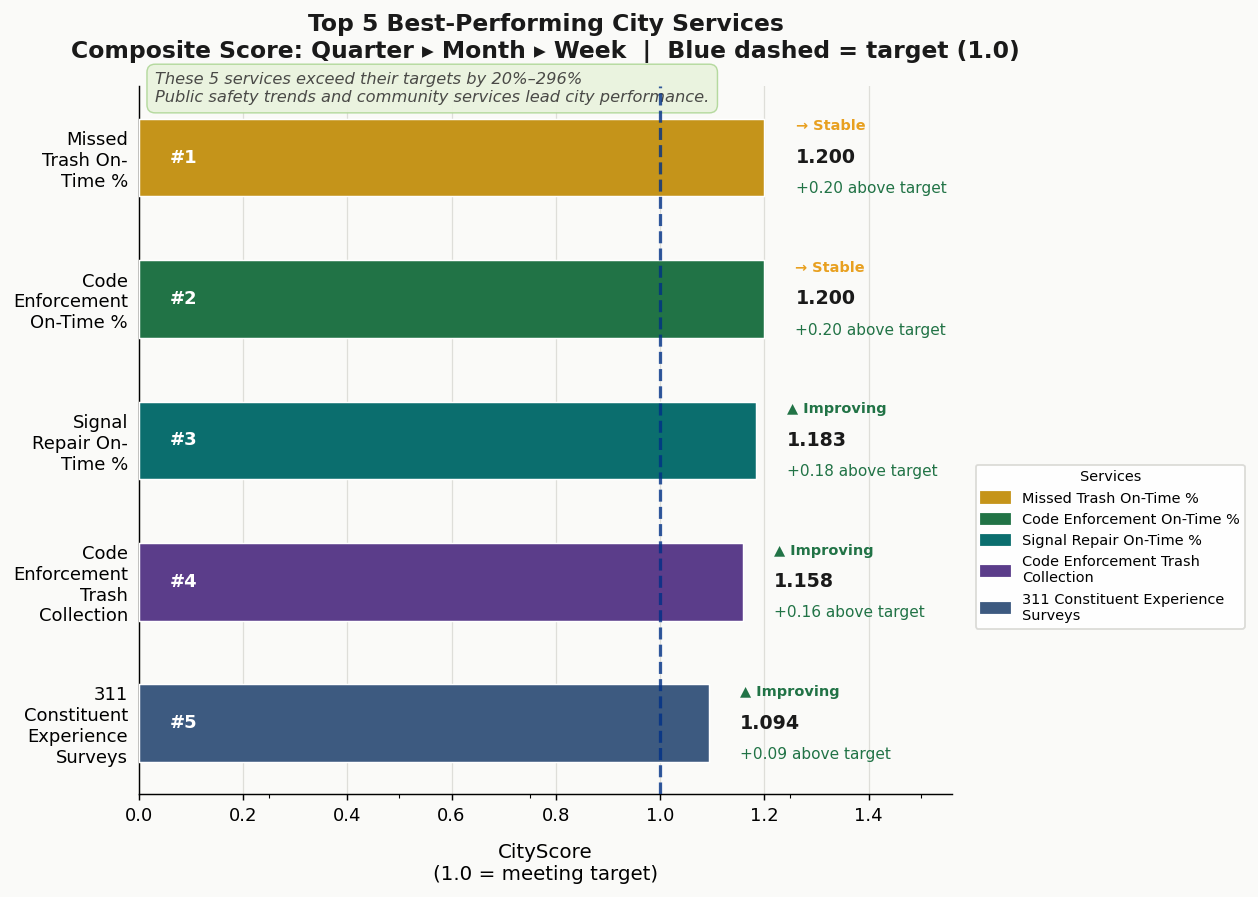

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.ticker import MultipleLocator
from textwrap import fill

# ── Figure setup ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

# ── Wrap long service labels into 2 lines ─────────────────────────────────
services = [
    fill(s.title(), width=11)
    for s in top5['metric_name'].tolist()[::-1]
]

scores     = top5['composite_score'].tolist()[::-1]
colors     = BAR_COLORS[::-1]
ranks      = top5['rank'].tolist()[::-1]
trends     = top5['trend_label'].tolist()[::-1]
trend_cols = top5['trend_color'].tolist()[::-1]
gaps       = top5['gap_above_target'].tolist()[::-1]

# ── Horizontal bars ───────────────────────────────────────────────────────
y_pos = np.arange(len(services))

bars = ax.barh(
    y_pos,
    scores,
    color=colors,
    height=0.55,
    edgecolor='white',
    linewidth=0.8,
    zorder=3
)

# ── Target line ────────────────────────────────────────────────────────────
ax.axvline(
    1.0,
    color=CITY_BLUE,
    linewidth=1.8,
    linestyle='--',
    alpha=0.8,
    zorder=4,
    label='Target = 1.0'
)

# ── Gridlines ──────────────────────────────────────────────────────────────
ax.xaxis.set_minor_locator(MultipleLocator(0.25))

ax.grid(
    axis='x',
    which='major',
    color='#DEDED9',
    linewidth=0.7,
    linestyle='-',
    zorder=0
)

# ── Labels inside/outside each bar ────────────────────────────────────────
for i, (bar, score, rank, trend, tcol, gap) in enumerate(
    zip(bars, scores, ranks, trends, trend_cols, gaps)
):

    bar_w = bar.get_width()
    bar_y = bar.get_y() + bar.get_height() / 2

    # Score value
    ax.text(
        bar_w + 0.06,
        bar_y,
        f'{score:.3f}',
        va='center',
        ha='left',
        fontsize=10.5,
        fontweight='bold',
        color='#1A1A1A'
    )

    # Gap label
    ax.text(
        bar_w + 0.06,
        bar_y - 0.22,
        f'+{gap:.2f} above target',
        va='center',
        ha='left',
        fontsize=8.5,
        color='#217346'
    )

    # Trend tag
    ax.text(
        bar_w + 0.06,
        bar_y + 0.22,
        trend,
        va='center',
        ha='left',
        fontsize=8,
        color=tcol,
        fontweight='bold'
    )

    # Rank label inside bar
    ax.text(
        0.06,
        bar_y,
        f'#{rank}',
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold',
        color='white',
        zorder=5
    )

# ── Y-axis labels ──────────────────────────────────────────────────────────
ax.set_yticks(y_pos)

ax.set_yticklabels(
    services,
    fontsize=10
)

ax.tick_params(
    axis='y',
    length=0,
    pad=6
)

# ── X-axis ────────────────────────────────────────────────────────────────
ax.set_xlabel(
    'CityScore\n(1.0 = meeting target)',
    fontsize=11,
    labelpad=10
)

ax.set_xlim(0, max(scores) * 1.30)

# ── Insight annotation box ────────────────────────────────────────────────
insight_text = (
    'These 5 services exceed their targets by 20%–296%\n'
    'Public safety trends and community services lead city performance.'
)

insight_text = (
    'These 5 services exceed their targets by 20%–296%\n'
    'Public safety trends and community services lead city performance.'
)

ax.text(
    0.02,          # horizontal position
    1.02,          # moved ABOVE plotting area
    insight_text,
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    color='#4A4A47',
    style='italic',
    clip_on=False,   # allow drawing outside axes
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='#EAF3DE',
        edgecolor='#B2D89B',
        linewidth=0.8,
        alpha=0.95
    )
)

# ── Legend (moved outside chart area) ─────────────────────────────────────
legend_patches = [
    mpatches.Patch(
        color=BAR_COLORS[i],
        label=fill(top5.iloc[i]['metric_name'].title(), width=28)
    )
    for i in range(len(top5))
]

ax.legend(
    handles=legend_patches,
    loc='center left',
    bbox_to_anchor=(1.02, 0.35),
    fontsize=8,
    framealpha=0.9,
    edgecolor='#D8D8D4',
    title='Services',
    title_fontsize=8
)

# ── Remove unnecessary borders ────────────────────────────────────────────
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Title ─────────────────────────────────────────────────────────────────
ax.set_title(
    'Top 5 Best-Performing City Services\n'
    'Composite Score: Quarter ▸ Month ▸ Week  |  Blue dashed = target (1.0)',
    fontsize=13,
    fontweight='bold',
    pad=16,
    color='#1A1A1A'
)

# ── Layout adjustment for external legend ─────────────────────────────────
plt.tight_layout(rect=[0, 0, 0.82, 1])

# ── Save & show ───────────────────────────────────────────────────────────
plt.savefig(
    'chart_top5_services.png',
    bbox_inches='tight',
    facecolor='#FAFAF8'
)

plt.show()

Bottom 5 services

In [ ]:
df_ranked = df_clean.sort_values('composite_score').reset_index(drop=True)
bottom5   = df_ranked.head(5).copy()
bottom5['rank'] = bottom5.index + 1 # Add rank column
bottom5_names = bottom5['metric_name'].tolist()

display(bottom5[['rank', 'metric_name', 'composite_score', 'perf_band', 'trend_label']])

detail = ['metric_name','day_score_final','week_score','month_score','quarter_score',
          'composite_score','gap_to_target','trend_delta_dw','trend_delta_wq','trend_delta_mq','trend_label','perf_band']
display(bottom5[detail])

,rank,metric_name,composite_score,perf_band,trend_label
0,1,SIGN INSTALLATION ON-TIME %,0.234375,CRITICAL,▼ Deteriorating
1,2,POTHOLE ON-TIME %,0.567010,CRITICAL,▲ Improving
2,3,ON-TIME PERMIT REVIEWS,0.669864,CRITICAL,→ Stable
3,4,CITY SERVICES SATISFACTION SURVEYS,0.766129,AT RISK,▲ Improving
4,5,GRAFFITI ON-TIME %,0.846154,AT RISK,▼ Deteriorating


,metric_name,day_score_final,week_score,month_score,quarter_score,composite_score,gap_to_target,trend_delta_dw,trend_delta_wq,trend_delta_mq,trend_label,perf_band
0,SIGN INSTALLATION ON-TIME %,NaN,0.100806,0.185811,0.234375,0.234375,-0.765625,NaN,-0.133569,-0.048564,▼ Deteriorating,CRITICAL
1,POTHOLE ON-TIME %,0.50,0.801887,0.661765,0.567010,0.567010,-0.432990,-0.301887,0.234876,0.094754,▲ Improving,CRITICAL
2,ON-TIME PERMIT REVIEWS,NaN,0.712821,0.695519,0.669864,0.669864,-0.330136,NaN,0.042956,0.025655,→ Stable,CRITICAL
3,CITY SERVICES SATISFACTION SURVEYS,1.25,0.816667,0.805556,0.766129,0.766129,-0.233871,0.433333,0.050538,0.039427,▲ Improving,AT RISK
4,GRAFFITI ON-TIME %,NaN,0.795455,0.730519,0.846154,0.846154,-0.153846,NaN,-0.050699,-0.115634,▼ Deteriorating,AT RISK


### Visualization of Bottom 5 Worst-Performing City Services

This chart highlights the five services with the lowest composite scores. Each bar's color indicates its performance band, and the annotations show the exact composite score and the short-term trend. The gray dashed line represents the target score of 1.0, while the red and orange dotted lines mark the 'Critical' (0.70) and 'At Risk' (0.90) thresholds, respectively.

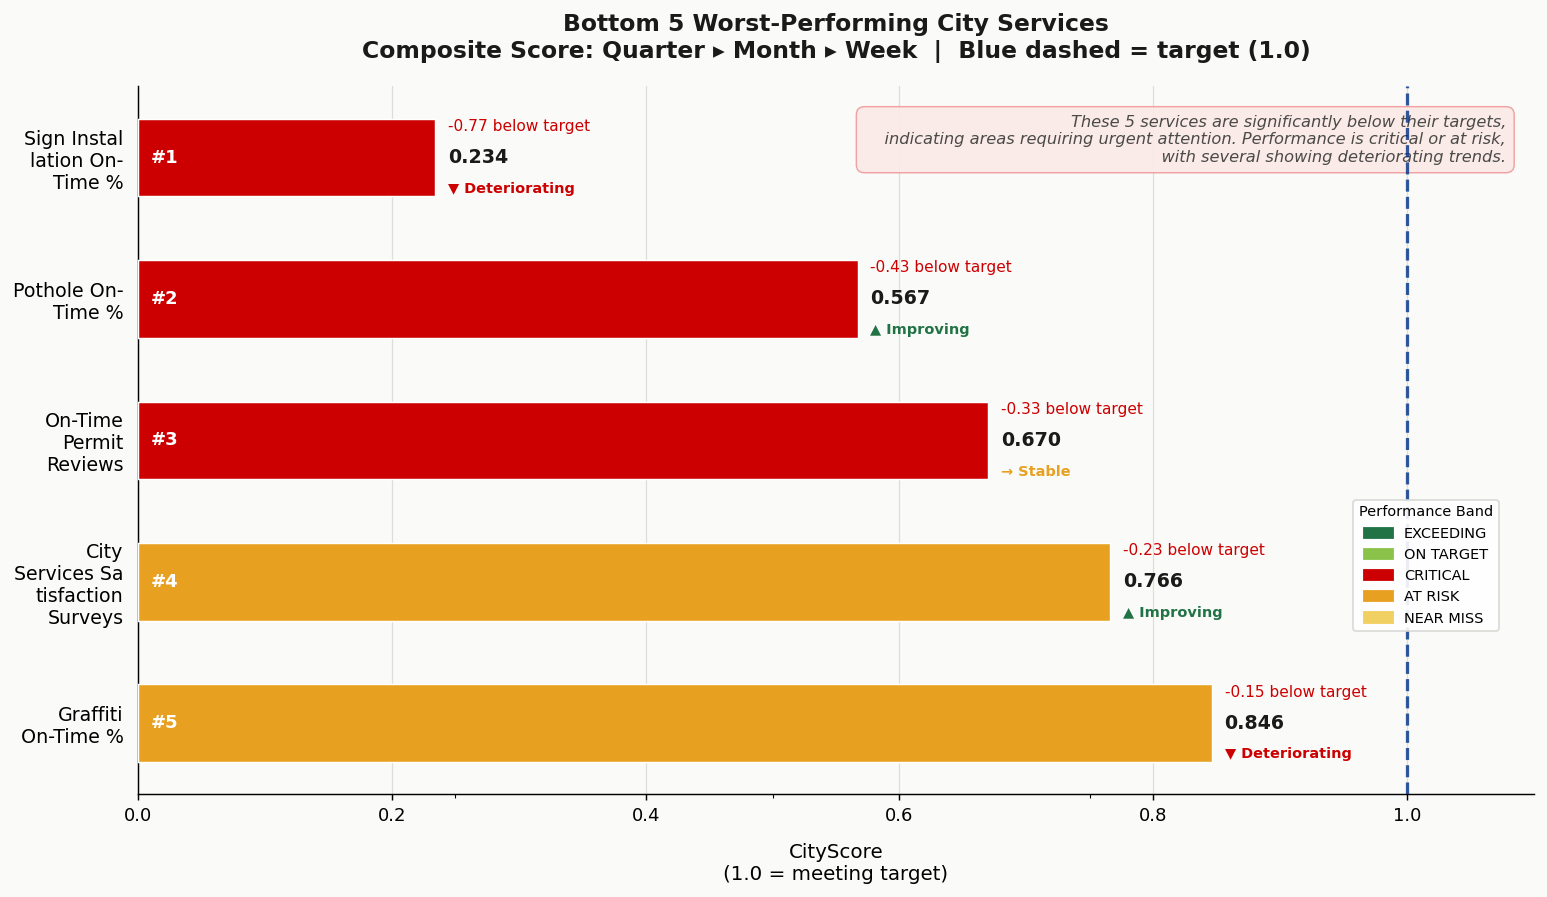

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from textwrap import fill

# Ensure bottom5 is sorted by composite_score ascending for consistent plotting
bottom5_sorted = bottom5.sort_values('composite_score', ascending=True).reset_index(drop=True)
bottom5_sorted['rank'] = bottom5_sorted.index + 1 # Assign ranks 1 to 5 for worst performers

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#FAFAF8')
ax.set_facecolor('#FAFAF8')

# Prepare data for plotting
services   = [fill(s.title(), width=11) for s in bottom5_sorted['metric_name'].tolist()]
scores     = bottom5_sorted['composite_score'].tolist()
colors     = [BAND_COLORS[band] for band in bottom5_sorted['perf_band']]
ranks      = bottom5_sorted['rank'].tolist()
trends     = bottom5_sorted['trend_label'].tolist()
trend_cols = bottom5_sorted['trend_color'].tolist()
gaps       = bottom5_sorted['gap_to_target'].tolist()

y_pos = np.arange(len(services))
bars  = ax.barh(y_pos, scores, color=colors, height=0.55,
                edgecolor='white', linewidth=0.8, zorder=3)

# Target line
ax.axvline(1.0, color=CITY_BLUE, linewidth=1.8, linestyle='--',
           alpha=0.8, zorder=4, label='Target = 1.0')

# Light gridlines
ax.xaxis.set_minor_locator(MultipleLocator(0.25))
ax.grid(axis='x', which='major', color='#DEDED9', linewidth=0.7,
        linestyle='-', zorder=0)

# ── Labels inside/outside each bar ────────────────────────
for i, (bar, score, rank, trend, tcol, gap) in enumerate(
        zip(bars, scores, ranks, trends, trend_cols, gaps)):

    bar_w = bar.get_width()
    bar_y = bar.get_y() + bar.get_height() / 2

    # Score value at end of bar
    ax.text(bar_w + 0.01, bar_y, f'{score:.3f}',
            va='center', ha='left', fontsize=10.5,
            fontweight='bold', color='#1A1A1A')

    # "-X.XX below target" label
    ax.text(bar_w + 0.01, bar_y - 0.22,
            f'{gap:.2f} below target' if gap < 0 else 'On target',
            va='center', ha='left', fontsize=8.5, color='#CC0000') # Use red for below target

    # Trend tag
    ax.text(bar_w + 0.01, bar_y + 0.22,
            trend, va='center', ha='left',
            fontsize=8, color=tcol, fontweight='bold')

    # Rank medal inside bar
    ax.text(0.01, bar_y, f'#{rank}',
            va='center', ha='left', fontsize=10,
            fontweight='bold', color='white', zorder=5)

# ── Y-axis: service names ──────────────────────
ax.set_yticks(y_pos)
ax.set_yticklabels(services, fontsize=10.5)
ax.tick_params(axis='y', length=0, pad=8)
ax.invert_yaxis() # To show the worst at the top

# ── X-axis ───────────────────────────────
ax.set_xlabel('CityScore\n(1.0 = meeting target)', fontsize=11, labelpad=10)
ax.set_xlim(0, max(1.1, max(scores) * 1.30)) # Ensure target is visible and some padding

# ── Insight annotation box ─────────────────────────
insight_text = (
    """These 5 services are significantly below their targets,
    indicating areas requiring urgent attention. Performance is critical or at risk,
    with several showing deteriorating trends."""
)
ax.text(
    0.98, 0.96, insight_text,
    transform=ax.transAxes,
    ha='right', va='top',
    fontsize=9, color='#4A4A47',
    style='italic',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FBE9E7',
              edgecolor='#EF9A9A', linewidth=0.8, alpha=0.9) # Reddish box for critical
)

# ── Colour legend ─────────────────────────
legend_patches = [
    mpatches.Patch(color=BAND_COLORS[band], label=band)
    for band in sorted(BAND_COLORS.keys(), key=lambda x: BAND_COLORS[x]) # Sort to keep order
]
ax.legend(handles=legend_patches, loc='lower right',
          bbox_to_anchor=(0.98, 0.22),
          fontsize=8, framealpha=0.9, edgecolor='#D8D8D4',
          title='Performance Band', title_fontsize=8)

# ── Title ────────────────────────
ax.set_title(
    'Bottom 5 Worst-Performing City Services\n'
    'Composite Score: Quarter ▸ Month ▸ Week  |  Blue dashed = target (1.0)',
    fontsize=13, fontweight='bold', pad=16, color='#1A1A1A'
)

plt.tight_layout()
plt.savefig('chart_bottom5_services.png', bbox_inches='tight', facecolor='#FAFAF8')
plt.show()

Services portfolio

PORTFOLIO HEALTH SCORE  (0–100)

Component 1 — Pass Rate (40 pts max)
    
    % of services at or above target × 0.40

  Component 2 — Severity Penalty (−30 pts max)
    
    CRITICAL services carry a heavier penalty than AT RISK
    penalty = (n_critical × 3 + n_atrisk × 1.5) / TOTAL × 10
    capped at 30

  Component 3 — Trend Momentum (30 pts max)
    
    net trend score = (improving − deteriorating) / TOTAL
    mapped to 0–30 range

  Total = Component1 − Component2 + Component3

Verdict thresholds:

70–100 → HEALTHY

45–69  → MIXED

0–44   → CONCERNING

In [ ]:
df = df_clean.copy()

# Bands
def perf_band(score):
    if pd.isna(score): return 'Unknown'
    if score < 0.70:   return 'CRITICAL'
    if score < 0.90:   return 'AT RISK'
    if score < 1.00:   return 'NEAR MISS'
    if score < 1.10:   return 'ON TARGET'
    return 'EXCEEDING'

df['perf_band']    = df['composite_score'].apply(perf_band)
df['trend_delta']  = df['week_score'] - df['quarter_score']

def trend_label(d):
    if pd.isna(d):    return 'Unknown'
    if d >=  0.05:    return 'Improving'
    if d <= -0.05:    return 'Deteriorating'
    return 'Stable'

df['trend_label'] = df['trend_delta'].apply(trend_label)

TOTAL = len(df)

# Band counts
band_counts = df['perf_band'].value_counts()
n_critical   = band_counts.get('CRITICAL',  0)
n_atrisk     = band_counts.get('AT RISK',   0)
n_nearmiss   = band_counts.get('NEAR MISS', 0)
n_ontarget   = band_counts.get('ON TARGET', 0)
n_exceeding  = band_counts.get('EXCEEDING', 0)

# Trend counts
trend_counts   = df['trend_label'].value_counts()
n_improving    = trend_counts.get('Improving',     0)
n_stable       = trend_counts.get('Stable',        0)
n_deteriorating= trend_counts.get('Deteriorating', 0)
n_unknown      = trend_counts.get('Unknown',       0)

# Derived variables
n_below_target = n_critical + n_atrisk + n_nearmiss
n_at_or_above  = n_ontarget + n_exceeding
mean_score     = df['composite_score'].mean()
median_score   = df['composite_score'].median()
pct_passing    = (n_at_or_above / TOTAL) * 100
pct_failing    = (n_below_target / TOTAL) * 100
pct_improving  = (n_improving / TOTAL) * 100
pct_deterior   = (n_deteriorating / TOTAL) * 100

comp1 = pct_passing * 0.40

raw_penalty = (n_critical * 3 + n_atrisk * 1.5) / TOTAL * 10
comp2 = min(raw_penalty, 30)

net_trend = (n_improving - n_deteriorating) / TOTAL   # -1 to +1
comp3 = (net_trend + 1) / 2 * 30                      # map to 0–30

health_score = comp1 - comp2 + comp3
health_score = max(0, min(100, health_score))          # clamp 0–100

# Verdict
if   health_score >= 70: verdict = 'HEALTHY';    verdict_color = CITY_GREEN
elif health_score >= 45: verdict = 'MIXED';      verdict_color = '#C5941A'
else:                    verdict = 'CONCERNING'; verdict_color = CITY_RED

# Print scorecard
print(f"\n  VERDICT  →  {verdict}  (Health Score: {health_score:.1f} / 100)\n")
print(f"  {'─'*55}")
print(f"  Component 1 — Pass rate      : {comp1:+.1f} pts  ({pct_passing:.0f}% of services at/above target)")
print(f"  Component 2 — Severity penalty: {-comp2:+.1f} pts  ({n_critical} CRITICAL + {n_atrisk} AT RISK services)")
print(f"  Component 3 — Trend momentum : {comp3:+.1f} pts  ({n_improving} improving, {n_deteriorating} deteriorating)")
print(f"  {'─'*55}")
print(f"  HEALTH SCORE                 : {health_score:.1f} / 100")
print(f"\n  Thresholds: 70–100 = HEALTHY | 45–69 = MIXED | 0–44 = CONCERNING")

print(f"""
  BAND DISTRIBUTION ({TOTAL} services)
  ┌─────────────────────────────────────────────────────┐
  │  CRITICAL  : {n_critical:>2} services  ({n_critical/TOTAL*100:.0f}%)  score < 0.70           │
  │  AT RISK   : {n_atrisk:>2} services  ({n_atrisk/TOTAL*100:.0f}%)  score 0.70–0.89        │
  │  NEAR MISS : {n_nearmiss:>2} services  ({n_nearmiss/TOTAL*100:.0f}%)  score 0.90–0.99        │
  │  ON TARGET : {n_ontarget:>2} services  ({n_ontarget/TOTAL*100:.0f}%)  score 1.00–1.09        │
  │  EXCEEDING : {n_exceeding:>2} services  ({n_exceeding/TOTAL*100:.0f}%)  score ≥ 1.10           │
  └─────────────────────────────────────────────────────┘

  TREND DISTRIBUTION
  ┌─────────────────────────────────────────────────────┐
  │  Improving     : {n_improving:>2} services  ({n_improving/TOTAL*100:.0f}%)                    │
  │  Stable        : {n_stable:>2} services  ({n_stable/TOTAL*100:.0f}%)                    │
  │  Deteriorating : {n_deteriorating:>2} services  ({n_deteriorating/TOTAL*100:.0f}%)                    │
  └─────────────────────────────────────────────────────┘

  SCORES
  ┌─────────────────────────────────────────────────────┐
  │  Mean score   : {mean_score:.3f}  (above 1.0 = portfolio average OK) │
  │  Median score : {median_score:.3f}  (half of services above/below)   │
  └─────────────────────────────────────────────────────┘
""")


  VERDICT  →  CONCERNING  (Health Score: 30.5 / 100)

  ───────────────────────────────────────────────────────
  Component 1 — Pass rate      : +21.1 pts  (53% of services at/above target)
  Component 2 — Severity penalty: -7.9 pts  (3 CRITICAL + 4 AT RISK services)
  Component 3 — Trend momentum : +17.4 pts  (8 improving, 5 deteriorating)
  ───────────────────────────────────────────────────────
  HEALTH SCORE                 : 30.5 / 100

  Thresholds: 70–100 = HEALTHY | 45–69 = MIXED | 0–44 = CONCERNING

  BAND DISTRIBUTION (19 services)
  ┌─────────────────────────────────────────────────────┐
  │  CRITICAL  :  3 services  (16%)  score < 0.70           │
  │  AT RISK   :  4 services  (21%)  score 0.70–0.89        │
  │  NEAR MISS :  2 services  (11%)  score 0.90–0.99        │
  │  ON TARGET :  3 services  (16%)  score 1.00–1.09        │
  │  EXCEEDING :  7 services  (37%)  score ≥ 1.10           │
  └─────────────────────────────────────────────────────┘

  TREND DISTRIBUTION
  ┌

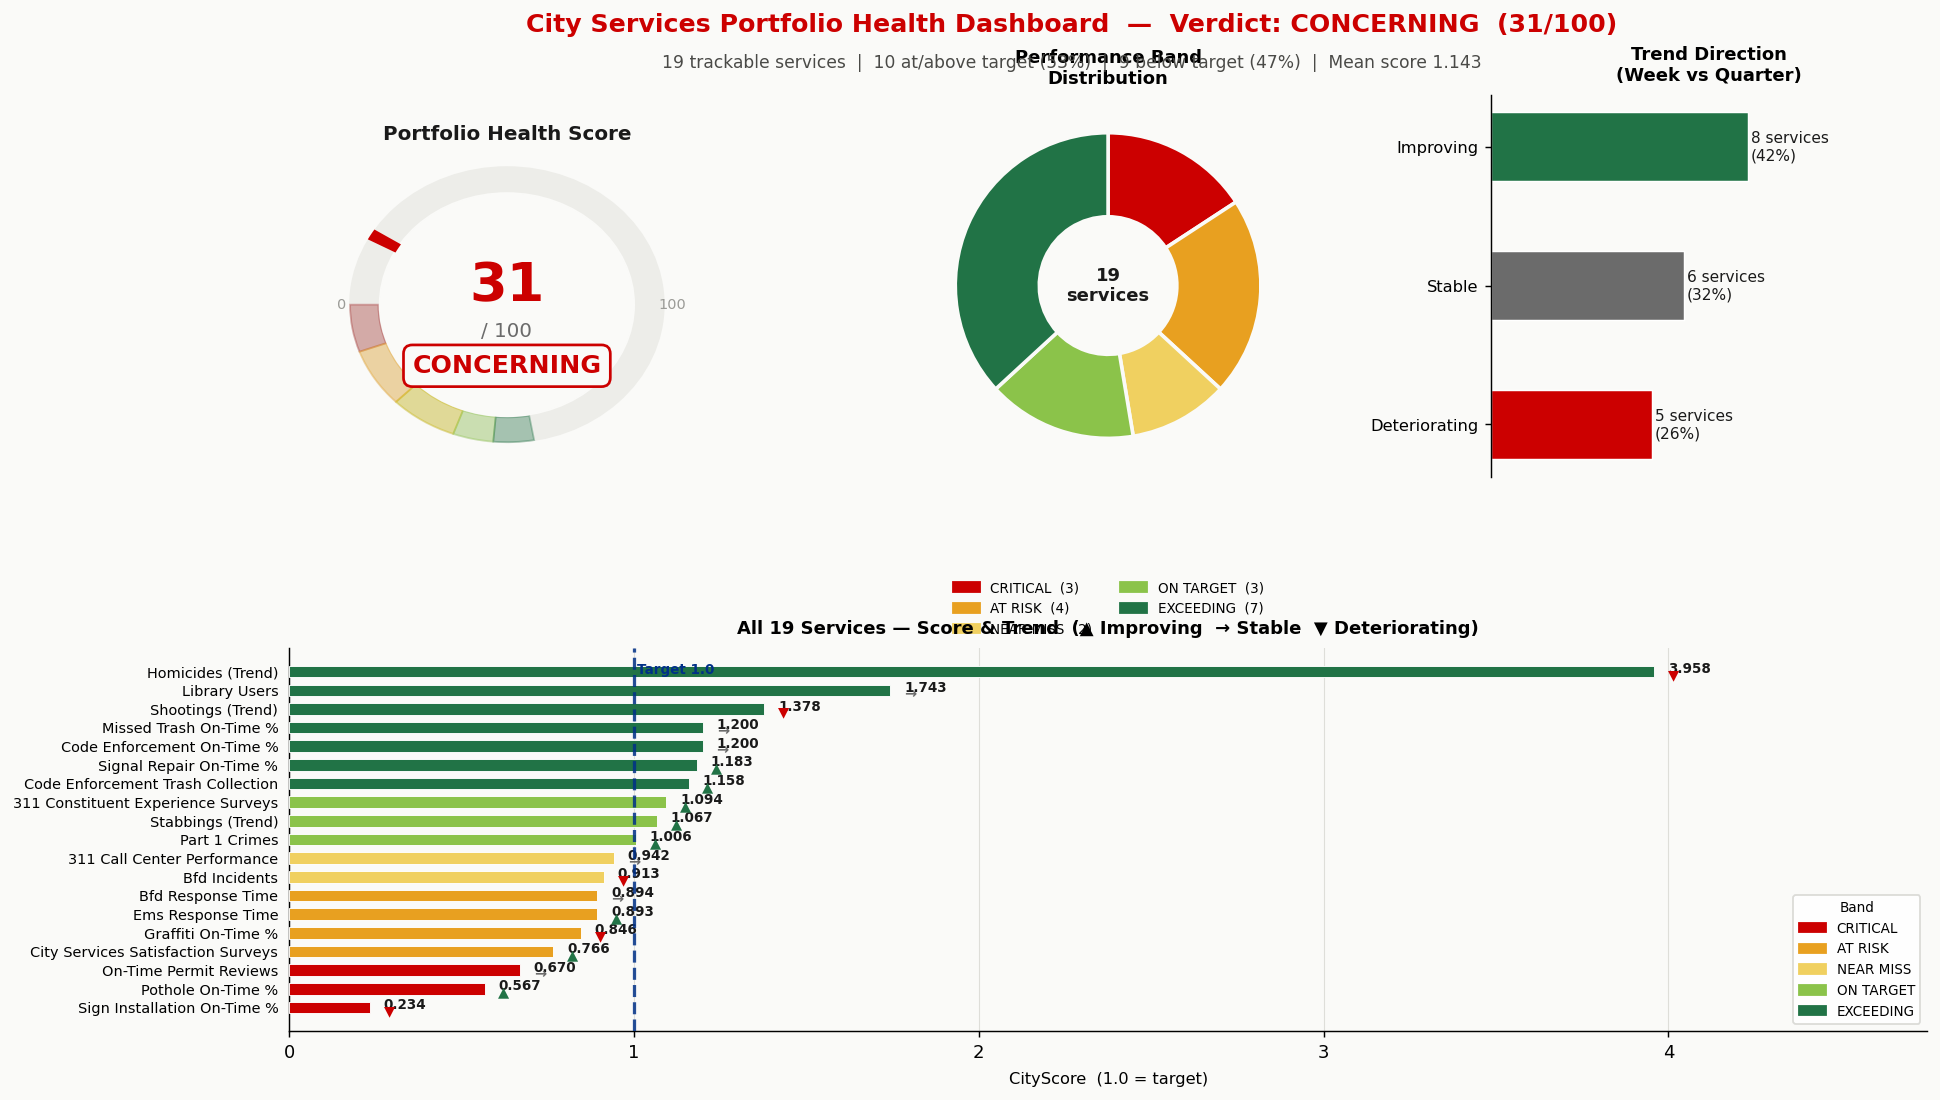

In [ ]:
fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor('#FAFAF8')

gs = gridspec.GridSpec(2, 3, figure=fig,
                       hspace=0.45, wspace=0.38,
                       left=0.07, right=0.97,
                       top=0.88, bottom=0.08)

ax_gauge  = fig.add_subplot(gs[0, 0])   # Health score gauge
ax_bands  = fig.add_subplot(gs[0, 1])   # Band distribution donut
ax_trend  = fig.add_subplot(gs[0, 2])   # Trend distribution bar
ax_all    = fig.add_subplot(gs[1, :])   # All services ranked

# ── PANEL 1 — HEALTH SCORE GAUGE ─────────────────────────────────────────
ax_gauge.set_xlim(0, 10)
ax_gauge.set_ylim(0, 10)
ax_gauge.axis('off')

# Background circle
bg = plt.Circle((5, 4.5), 3.6, color='#EDEDE9', zorder=1)
ax_gauge.add_patch(bg)

# Colored arc — simple wedge approach
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, FancyArrowPatch

# Gradient ring using colored wedges
wedge_colors = ['#A32D2D','#E8A020','#C8B400','#8BC34A','#217346']
wedge_ranges = [20, 25, 25, 15, 15]   # spans for each color zone
start_angle  = 180
for wc, wr in zip(wedge_colors, wedge_ranges):
    wedge = plt.matplotlib.patches.Wedge(
        (5, 4.5), 3.6, start_angle, start_angle + wr,
        width=0.65, color=wc, alpha=0.35, zorder=2
    )
    ax_gauge.add_patch(wedge)
    start_angle += wr

# Score indicator wedge
score_angle = 180 - (health_score / 100) * 100
needle_wedge = plt.matplotlib.patches.Wedge(
    (5, 4.5), 3.6, score_angle - 2, score_angle + 2,
    width=0.68, color=verdict_color, alpha=1.0, zorder=4
)
ax_gauge.add_patch(needle_wedge)

# White inner circle
inner = plt.Circle((5, 4.5), 2.92, color='#FAFAF8', zorder=3)
ax_gauge.add_patch(inner)

# Score text
ax_gauge.text(5, 5.0, f'{health_score:.0f}',
              ha='center', va='center', fontsize=30,
              fontweight='bold', color=verdict_color, zorder=5)
ax_gauge.text(5, 3.8, '/ 100', ha='center', va='center',
              fontsize=11, color='#6B6B6B', zorder=5)
ax_gauge.text(5, 9.2, 'Portfolio Health Score',
              ha='center', va='top', fontsize=11, fontweight='bold', color='#1A1A1A')
ax_gauge.text(5, 2.9, verdict,
              ha='center', va='center', fontsize=14,
              fontweight='bold', color=verdict_color, zorder=5,
              bbox=dict(boxstyle='round,pad=0.35', facecolor='#FAFAF8',
                        edgecolor=verdict_color, linewidth=1.5))

# Scale labels
ax_gauge.text(1.2, 4.5, '0', ha='center', va='center',
              fontsize=8, color='#9B9B97')
ax_gauge.text(8.8, 4.5, '100', ha='center', va='center',
              fontsize=8, color='#9B9B97')

# ── PANEL 2 — BAND DONUT ─────────────────────────────────────────────────
ax_bands.set_facecolor('#FAFAF8')
bands_order  = ['CRITICAL','AT RISK','NEAR MISS','ON TARGET','EXCEEDING']
bands_counts = [band_counts.get(b, 0) for b in bands_order]
bands_clrs   = [BAND_COLORS[b] for b in bands_order]

wedges, _ = ax_bands.pie(
    bands_counts, colors=bands_clrs,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.55, edgecolor='#FAFAF8', linewidth=2)
)

ax_bands.text(0, 0, f'{TOTAL}\nservices', ha='center', va='center',
              fontsize=10, fontweight='bold', color='#1A1A1A')
ax_bands.set_title('Performance Band\nDistribution',
                   fontsize=10, fontweight='bold', pad=6)

legend_patches = [
    mpatches.Patch(color=BAND_COLORS[b], label=f'{b}  ({band_counts.get(b,0)})')
    for b in bands_order if band_counts.get(b, 0) > 0
]
ax_bands.legend(handles=legend_patches, loc='lower center',
                bbox_to_anchor=(0.5, -0.45), # Adjusted from -0.28 to -0.45
                fontsize=7.5, framealpha=0, ncol=2)

# ── PANEL 3 — TREND BAR ──────────────────────────────────────────────────
ax_trend.set_facecolor('#FAFAF8')
trend_labels_list  = ['Improving', 'Stable', 'Deteriorating']
trend_vals         = [n_improving, n_stable, n_deteriorating]
trend_clrs         = [CITY_GREEN, '#6B6B6B', CITY_RED]

bars = ax_trend.barh(trend_labels_list[::-1], trend_vals[::-1],
                     color=trend_clrs[::-1], height=0.5,
                     edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, trend_vals[::-1]):
    ax_trend.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                  f'{val} services\n({val/TOTAL*100:.0f}%)',
                  va='center', ha='left', fontsize=8.5, color='#1A1A1A')

ax_trend.set_xlim(0, max(trend_vals) * 1.7)
ax_trend.set_xlabel('Number of services', fontsize=9)
ax_trend.set_title('Trend Direction\n(Week vs Quarter)',
                   fontsize=10, fontweight='bold', pad=8)
ax_trend.tick_params(axis='both', labelsize=9)
ax_trend.spines['bottom'].set_visible(False)
ax_trend.xaxis.set_visible(False)

# ── PANEL 4 — ALL SERVICES RANKED ────────────────────────────────────────
ax_all.set_facecolor('#FAFAF8')
df_sorted = df.sort_values('composite_score', ascending=True).reset_index(drop=True)
svc_names = df_sorted['metric_name'].str.title()
svc_scores= df_sorted['composite_score']
svc_colors= [BAND_COLORS[b] for b in df_sorted['perf_band']]
svc_trends= df_sorted['trend_label']

y = np.arange(len(df_sorted))
bars_all = ax_all.barh(y, svc_scores, color=svc_colors,
                       height=0.62, edgecolor='white', linewidth=0.5, zorder=3)

ax_all.axvline(1.0, color=CITY_BLUE, linewidth=1.8,
               linestyle='--', alpha=0.85, zorder=4)
ax_all.grid(axis='x', color='#DEDED9', linewidth=0.6, zorder=0)

# Score + trend labels
for bar, score, trend in zip(bars_all, svc_scores, svc_trends):
    bw = bar.get_width()
    by = bar.get_y() + bar.get_height() / 2
    ax_all.text(bw + 0.04, by + 0.15, f'{score:.3f}',
                va='center', ha='left', fontsize=7.5, fontweight='bold', color='#1A1A1A')
    arrow = '▲' if trend == 'Improving' else ('▼' if trend == 'Deteriorating' else '→')
    clr   = CITY_GREEN if arrow == '▲' else (CITY_RED if arrow == '▼' else '#6B6B6B')
    ax_all.text(bw + 0.04, by - 0.18, arrow,
                va='center', ha='left', fontsize=8, color=clr, fontweight='bold')

ax_all.set_yticks(y)
ax_all.set_yticklabels(svc_names, fontsize=8)
ax_all.tick_params(axis='y', length=0, pad=6)
ax_all.set_xlim(0, svc_scores.max() * 1.20)
ax_all.set_xlabel('CityScore  (1.0 = target)', fontsize=9, labelpad=6)
ax_all.text(1.01, len(df_sorted) - 0.5, 'Target 1.0',
            color=CITY_BLUE, fontsize=7.5, fontweight='bold', va='top')

# Band legend
leg_patches = [mpatches.Patch(color=v, label=k) for k, v in BAND_COLORS.items()]
ax_all.legend(handles=leg_patches, loc='lower right', fontsize=7.5,
              framealpha=0.9, edgecolor='#D8D8D4', title='Band', title_fontsize=7.5)

ax_all.set_title('All 19 Services — Score & Trend  (▲ Improving  → Stable  ▼ Deteriorating)',
                 fontsize=10, fontweight='bold', pad=8)

# ── Main title ─────────────────────────────────────────────────────────────
fig.text(0.5, 0.95,
         f'City Services Portfolio Health Dashboard  —  Verdict: {verdict}  ({health_score:.0f}/100)',
         ha='center', va='top', fontsize=14, fontweight='bold', color=verdict_color)
fig.text(0.5, 0.915,
         f'19 trackable services  |  {n_at_or_above} at/above target ({pct_passing:.0f}%)  '
         f'|  {n_below_target} below target ({pct_failing:.0f}%)  '
         f'|  Mean score {mean_score:.3f}',
         ha='center', va='top', fontsize=9.5, color='#4A4A47')

plt.savefig('chart_portfolio_health.png', bbox_inches='tight', facecolor='#FAFAF8')
plt.show()